# Анализ главных компонент (PCA) для функциональных и структурных переменных
В этом ноутбуке мы выполняем уменьшение размерности (PCA) для двух наборов переменных:
1. **PC_Func** (потенциально отражающий геометрию/объемы)
2. **PC_Struct** (потенциально отражающий функцию/механику)

*Примечание: названия `PC_Func` и `PC_Struct` сохранены в соответствии с запросом, хотя первый набор больше связан со структурой/геометрией, а второй — с функцией.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import os

# Настройка стилей для графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Создание директории для графиков
output_dir = '../output/figures'
os.makedirs(output_dir, exist_ok=True)

In [2]:
# Путь к датасету
file_path = '../data/final_analysis_dataset_new.xlsx'
df = pd.read_excel(file_path)

print(f"Размер датасета: {df.shape}")

Размер датасета: (153, 214)


In [3]:
# Списки переменных для PCA (удалены показатели по Тейхольцу и ССОУ)
pc_func_vars = [
    'echo_lv_sphericity_index_end_diastolic_ratio', 
    'echo_lv_end_diastolic_volume_index_simpson_ml_m2', 
    'dicor_sm_kdtr_cv_pct'
]

pc_struct_vars = [
    'echo_lv_ejection_fraction_simpson_pct', 
    'echo_lv_strain_rate_cv_pct', 
    'echo_lv_strain_plus_cv_pct'
]

# Проверка наличия переменных в датасете
missing_func = [v for v in pc_func_vars if v not in df.columns]
missing_struct = [v for v in pc_struct_vars if v not in df.columns]

if missing_func:
    print(f"Отсутствуют переменные для PC_Func: {missing_func}")
    pc_func_vars = [v for v in pc_func_vars if v in df.columns]
if missing_struct:
    print(f"Отсутствуют переменные для PC_Struct: {missing_struct}")
    pc_struct_vars = [v for v in pc_struct_vars if v in df.columns]

## Подготовка данных
PCA требует числовых данных без пропусков. Сначала мы выполняем **обработку выбросов (Winsorization 1.5 IQR)**, ограничивая экстремальные значения. Затем используем медианное заполнение (`SimpleImputer(strategy='median')`), так как при удалении строк с пропусками в датасете не остается пациентов. В конце данные стандартизируются (`StandardScaler`) (mean=0, variance=1).

In [4]:
# Подготовка данных (Очистка выбросов, Медианная импьютация и Стандартизация)
def prepare_data(data, features):
    subset = data[features].copy()
    
    # Очистка выбросов (Winsorization по методу 1.5 * IQR)
    # Значения за пределами усов заменяются на граничные
    for col in features:
        Q1 = subset[col].quantile(0.25)
        Q3 = subset[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        subset[col] = np.clip(subset[col], lower_bound, upper_bound)
    
    # Медианная импьютация
    imputer = SimpleImputer(strategy='median')
    subset_imputed = imputer.fit_transform(subset)
    
    # Стандартизация
    scaler = StandardScaler()
    subset_scaled = scaler.fit_transform(subset_imputed)
    
    return pd.DataFrame(subset_scaled, columns=features, index=subset.index), subset.index

df_func_scaled, valid_func = prepare_data(df, pc_func_vars)
df_struct_scaled, valid_struct = prepare_data(df, pc_struct_vars)

print(f"Данные обработаны (медианное заполнение пропусков).")

Данные обработаны (медианное заполнение пропусков).


## Расчет компонент

In [5]:
# Выполнение PCA
pca_func = PCA(n_components=1)
pc_func = pca_func.fit_transform(df_func_scaled)

pca_struct = PCA(n_components=1)
pc_struct = pca_struct.fit_transform(df_struct_scaled)

df['PC_Func'] = np.nan
df.loc[valid_func, 'PC_Func'] = pc_func[:, 0]

df['PC_Struct'] = np.nan
df.loc[valid_struct, 'PC_Struct'] = pc_struct[:, 0]

print(f"PC_Func Explained Variance: {pca_func.explained_variance_ratio_[0]:.2%}")
print(f"PC_Struct Explained Variance: {pca_struct.explained_variance_ratio_[0]:.2%}")

PC_Func Explained Variance: 38.59%
PC_Struct Explained Variance: 53.05%


## Визуализации
Нагрузки (loadings) показывают, какой вклад каждая исходная переменная вносит в главную компоненту.

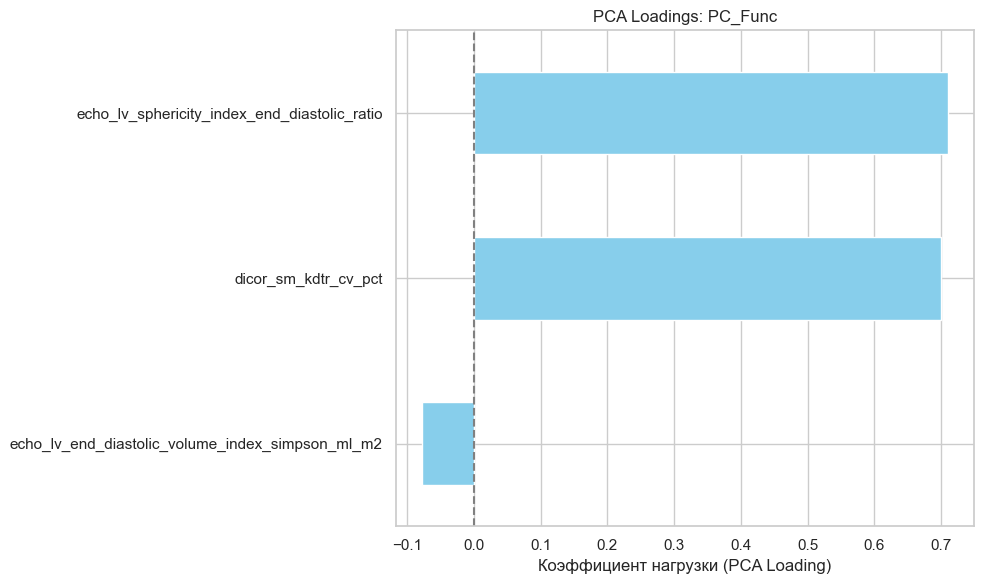

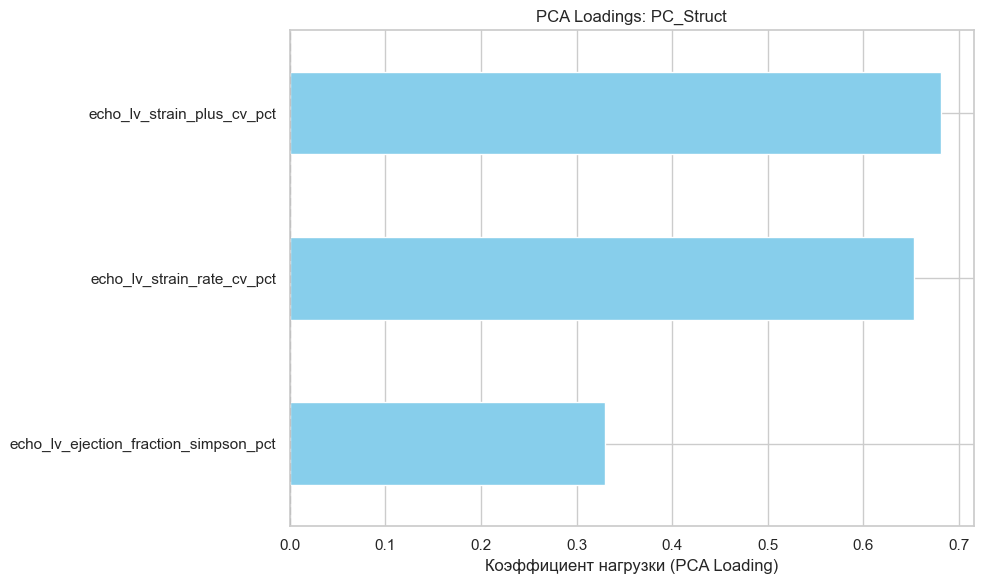

In [6]:
# Визуализация нагрузок (Loadings)
def plot_loadings(pca_model, features, title, filename):
    loadings = pd.Series(pca_model.components_[0], index=features)
    loadings = loadings.sort_values(ascending=True)
    
    plt.figure(figsize=(10, 6))
    loadings.plot(kind='barh', color='skyblue')
    plt.title(title)
    plt.xlabel('Коэффициент нагрузки (PCA Loading)')
    plt.axvline(x=0, color='grey', linestyle='--')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/{filename}', dpi=300)
    plt.show()

plot_loadings(pca_func, pc_func_vars, 'PCA Loadings: PC_Func', 'pca_loadings_func.png')
plot_loadings(pca_struct, pc_struct_vars, 'PCA Loadings: PC_Struct', 'pca_loadings_struct.png')

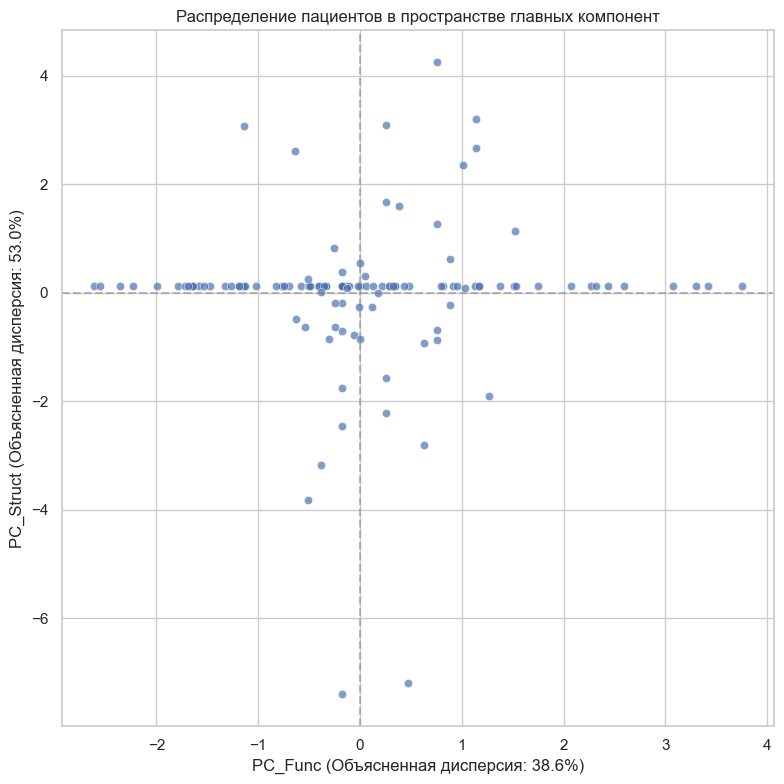

In [7]:
# Диаграмма рассеяния PC_Func vs PC_Struct
plt.figure(figsize=(8, 8))
sns.scatterplot(x='PC_Func', y='PC_Struct', data=df, alpha=0.7)
plt.title('Распределение пациентов в пространстве главных компонент')
plt.xlabel(f'PC_Func (Объясненная дисперсия: {pca_func.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC_Struct (Объясненная дисперсия: {pca_struct.explained_variance_ratio_[0]:.1%})')
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{output_dir}/pca_scatter_func_vs_struct.png', dpi=300)
plt.show()

In [8]:
# Сохранение обновленного датасета
output_dataset = '../data/final_analysis_dataset_with_pca.xlsx'
df.to_excel(output_dataset, index=False)
print(f"Датасет с компонентами сохранен в: {output_dataset}")

Датасет с компонентами сохранен в: ../data/final_analysis_dataset_with_pca.xlsx
